Nurul Sufia
230212010
Praktikum 5

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten
from keras.models import Sequential

In [2]:
import pandas as pd
df = pd.read_csv('/content/typedCSV.csv')

print(df.shape)
print(df['label'].unique())

(3197, 785)
[0 1 2 3]


In [3]:
# SECTION 3 - PISAHKAN FITUR DAN LABEL
X = df.drop('label', axis=1).values
y = df['label'].values

print('Jumlah data:', len(X))
print('Jumlah class:', len(np.unique(y)))

Jumlah data: 3197
Jumlah class: 4


In [4]:
# SECTION 4 - RESHAPE GAMBAR (28x28 pixel, 1 channel)
X = X.reshape(-1, 28, 28, 1)
X = X.astype('float32') / 255.0
print('Shape X:', X.shape)

# SECTION 5 - MEMBUAT LABEL
labels = y.tolist()
print('Jumlah label:', len(labels))

Shape X: (3197, 28, 28, 1)
Jumlah label: 3197


In [16]:
# SECTION 7 - MEMBANGUN MODEL CNN

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

num_classes = 10

input_shape = (28, 28, 1)

model = Sequential([

    Conv2D(32, (3,3),
           activation='relu',
           padding='same',
           input_shape=input_shape),


    Conv2D(64, (3,3),
           activation='relu',
           padding='same'),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3),
           activation='relu',
           padding='same'),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc']
)

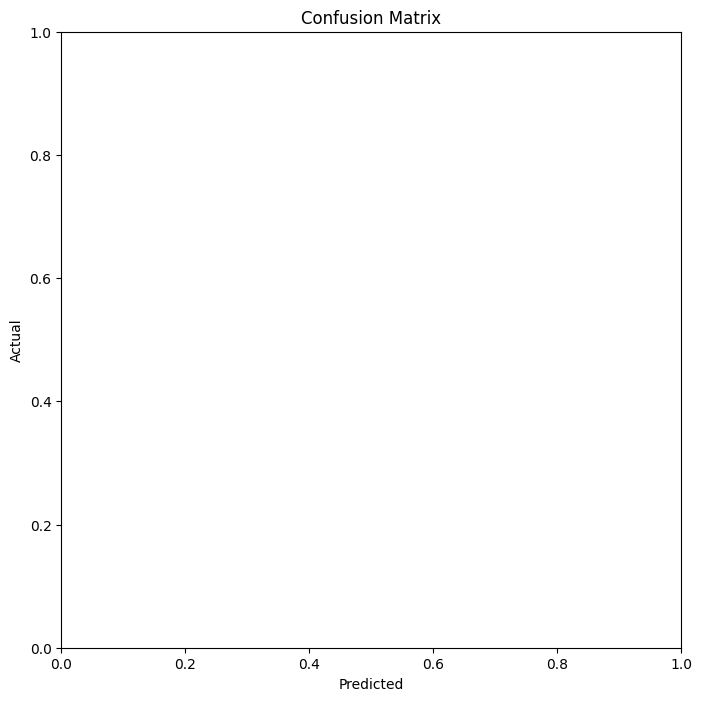

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8,8))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
for i, miss in enumerate(misses[:5]):
    plt.figure(figsize=(2, 2))
    plt.imshow(X_test[miss].reshape(28, 28), cmap='gray')
    plt.title('actual: {}\npredicted: {}'.format(
        label_names[y_test[miss]],
        label_names[predictions[miss]]
    ))
    plt.show()